In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision

from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

print(torch.__version__)

2.10.0+cu128


In [3]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/kmader
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_2


In [4]:

metadata = pd.read_csv(
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"
)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [6]:
metadata["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [7]:
import os
from glob import glob

image_paths = {}

for folder in [
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1",
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"
]:
    for path in glob(os.path.join(folder, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(path))[0]
        image_paths[image_id] = path

print(f"Found {len(image_paths)} images.")

Found 10015 images.


In [8]:
metadata["path"] = metadata["image_id"].map(image_paths)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...


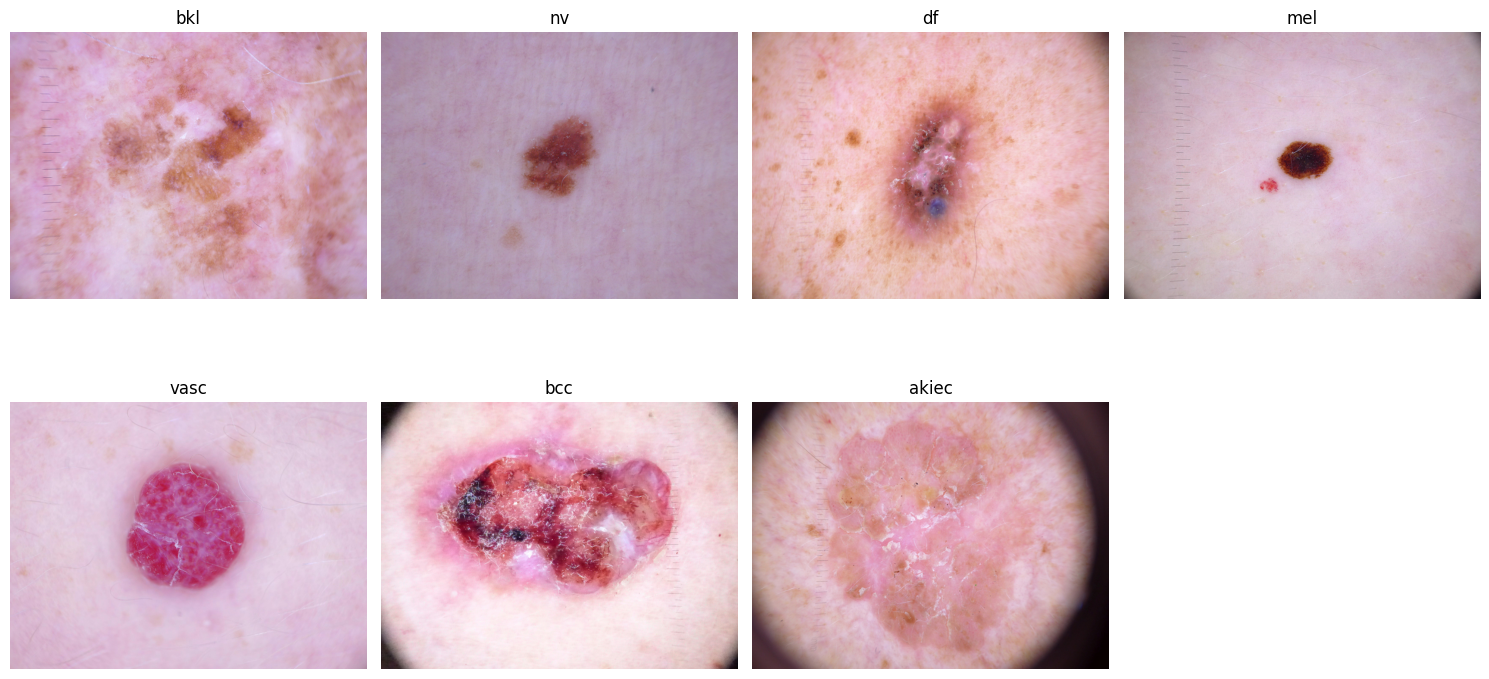

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

classes = metadata["dx"].unique()

plt.figure(figsize=(15, 8))

for i, lesion in enumerate(classes):
    sample = metadata[metadata["dx"] == lesion].iloc[0]

    img = Image.open(sample["path"])

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(lesion)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
metadata["label"] = label_encoder.fit_transform(metadata["dx"])
metadata[["dx", "label"]].head()

,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [11]:
mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))

print(mapping)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [12]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    metadata,
    test_size=0.2,
    stratify=metadata["label"],
    random_state=42
)

print(len(train_df), len(val_df))

8012 2003


In [13]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [14]:
from torch.utils.data import Dataset
from PIL import Image

class SkinCancerDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["path"]).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
train_dataset = SkinCancerDataset(train_df, transform=train_transform)

val_dataset = SkinCancerDataset(val_df, transform=val_transform)

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [17]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


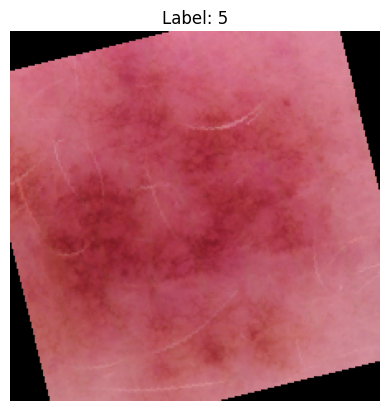

In [18]:
plt.imshow(images[0].permute(1, 2, 0))
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [19]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 229MB/s]


In [20]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [21]:
import torch.nn as nn

model.classifier[1] = nn.Linear(
    in_features=1280,
    out_features=7
)

In [22]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [27]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/10, Loss: 0.5236
Epoch 2/10, Loss: 0.4496
Epoch 3/10, Loss: 0.3901
Epoch 4/10, Loss: 0.3625
Epoch 5/10, Loss: 0.3028
Epoch 6/10, Loss: 0.2849
Epoch 7/10, Loss: 0.2547
Epoch 8/10, Loss: 0.2357
Epoch 9/10, Loss: 0.2113
Epoch 10/10, Loss: 0.1881


In [28]:
torch.save(model.state_dict(), "best_model.pth")

In [30]:
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [31]:
from sklearn.metrics import accuracy_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)

print(f"Validation Accuracy: {accuracy*100:.2f}%")

Validation Accuracy: 87.47%


In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       akiec       0.68      0.77      0.72        65
         bcc       0.85      0.78      0.81       103
         bkl       0.77      0.72      0.75       220
          df       0.76      0.70      0.73        23
         mel       0.75      0.58      0.65       223
          nv       0.92      0.97      0.94      1341
        vasc       0.96      0.82      0.88        28

    accuracy                           0.87      2003
   macro avg       0.81      0.76      0.78      2003
weighted avg       0.87      0.87      0.87      2003



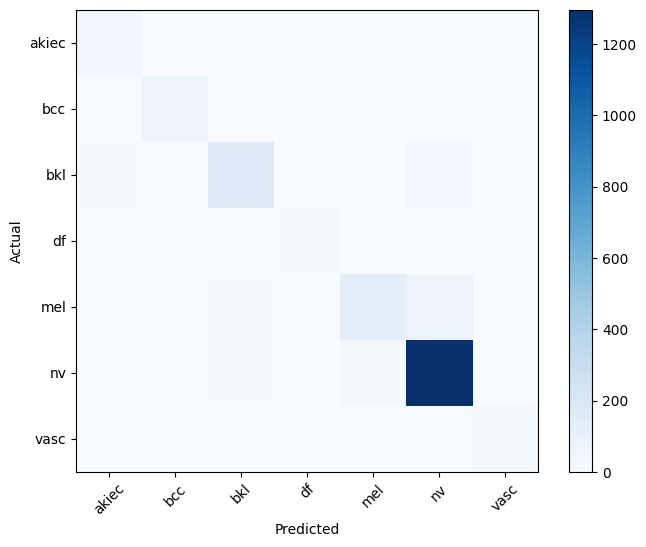

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(7), label_encoder.classes_, rotation=45)
plt.yticks(range(7), label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
torch.save(model.state_dict(), "skin_cancer_model.pth")

In [42]:
from IPython.display import FileLink
# Do not include the "/kaggle/working/" prefix in the string path
FileLink(r'skin_cancer_model.pth') 


/kaggle/working/skin_cancer_model.pth